# Maximum probability of loss

We are investing in two assets. Let $R_1$ and $R_2$ be the random variables corresponding to the returns. Both $R_1$ and $R_2$ have Gaussian marginal distributions, with known means $\mu_1=5$ and $\mu_2=15$ and known standard deviations $\sigma_1=3$ and $\sigma_2=10$. Moreover, we are given the correlation coefficient $\rho=-0.3$, i.e.,$$\mathbf{E} (R_1-\mu_1) (R_2-\mu_2)  = \rho \sigma_1 \sigma_2.$$

Use a linear programming solver to find the worst-case (maximum) probability of a loss, i.e, $p^\mathrm{loss} = \mathbf{Pr} (R_1+R_2 \leq 0)$. Compare the results to the case when $R_1$ and $R_2$ are jointly Gaussian.  Then,
  
  $$R_1+R_2 \sim \mathcal N(\mu_1+\mu_2,\sigma_1^2+\sigma_2^2+2 \rho \sigma_1\sigma_2),$$
  
  which for our parameters gives $p^\mathrm{loss} \approx 0.018$. 
  
This is an infinite-dimensional optimization problem, since you must maximize $p^\mathrm{loss}$ over an infinite-dimensional set of joint distributions. To (approximately) solve it, we discretize the values that $R_1$ and $R_2$ can take on, to $n=100$ values $r_1,\ldots, r_n$, uniformly spaced from $r_1=-20$ to $r_n=+50$. 
We use the discretized marginals $p^{(1)}$ and $p^{(2)}$ for $R_1$ and $R_2$, given by$$p^{(k)}_i =\mathbf{Pr}(R_k = r_i) =\frac{ \exp \left(-(r_i-\mu_k)^2/(2 \sigma_k^2) \right)}{\sum_{j=1}^n  \exp \left( -(r_j-\mu_k)^2/(2 \sigma_k^2) \right)},$$
  for $k=1,2$, $i=1, \ldots, n$.
  
  Plot the joint distribution that yields the maximum value of $p^\mathrm{loss}$ using e.g. ``matplotlib``'s ``contour`` (see the code below for two jointly Gaussian variables). Interpret what you see. 
  
  ---- 
*This exercise originates from "Additional Exercises" collection for Convex Optimization textbook of S. Boyd and L. Vandenberghe. Used under permission*

In [8]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [9]:
mu = (5, 15)
sigma = (3, 10)
rho = -0.3
n = 100
r=np.linspace(-20,50,n)

Below we create the marginals of the discrete distrubution

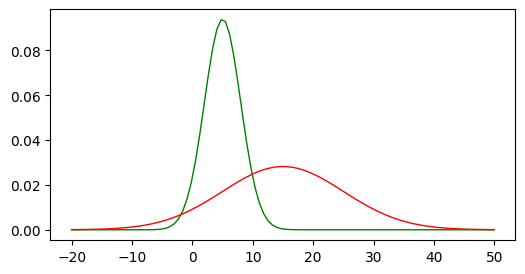

In [10]:
e = lambda k, i : math.exp(-(r[i]-mu[k])**2 / (2*sigma[k]**2))
p_mar = np.zeros((n,n))
for k in [0,1]:
    sum_exp = sum(e(k,i) for i in range(100))
    for i in range(n):
        p_mar[k][i] = e(k,i)/sum_exp

plt.rcParams['figure.figsize'] = [6, 3]
fig = plt.figure()
plt.plot(r,p_mar[0], 'g', linewidth=1)
plt.plot(r,p_mar[1], 'r', linewidth=1)

Let's also draw the joint Gaussian distribution, just for fun.

In [11]:
#calculate probability of loss
from scipy.stats import norm
norm.cdf(0, sum(mu), math.sqrt(sigma[0]**2 + sigma[1]**2 + 2*rho*sigma[0]*sigma[1]))

np.float64(0.018015843109116775)

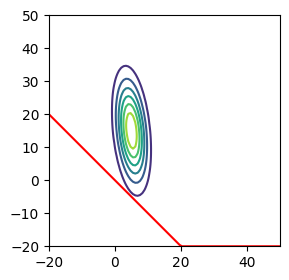

In [12]:
from scipy.stats import multivariate_normal

# Initializing the covariance matrix
cov = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]], [rho*sigma[0]*sigma[1], sigma[1]**2]])

# Generating a Gaussian bivariate distribution
# with given mean and covariance matrix
distr = multivariate_normal(cov = cov, mean = mu)

# Generating a meshgrid complacent with
# the 3-sigma boundary
X, Y = np.meshgrid(r,r)

# Generating the density function
# for each point in the meshgrid
pdf = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        pdf[i,j] = distr.pdf([X[i,j], Y[i,j]])

plt.axes().set_aspect('equal')
plt.contour(X, Y, pdf)
plt.plot(r,list(map(lambda x: max(x,-20), -r)),color="r") #R1+R2==0 red line


Above one can see that the two variables are indeed negatively correlated. 
The region below the red line is the loss event (we see that it is indeed unlikely)

## LP formulation

We want to find the worst-case (maximum) probability of loss over all joint distributions $P$ on $\{r_1,\ldots,r_n\}^2$ that are consistent with the given marginals and correlation.

**Variables:** $P_{ij} \geq 0$ — the joint distribution matrix ($n \times n$).

**Objective:** maximize $\sum_{i,j:\, r_i+r_j \leq 0} P_{ij}$

**Constraints:**
- Row marginals: $\sum_j P_{ij} = p^{(1)}_i$ for all $i$
- Column marginals: $\sum_i P_{ij} = p^{(2)}_j$ for all $j$
- Correlation: $\sum_{i,j} (r_i - \mu_1)(r_j - \mu_2)\, P_{ij} = \rho\,\sigma_1\sigma_2$

In [18]:
import cvxpy as cp

# Decision variable: joint distribution matrix P (n x n), non-negative
P = cp.Variable((n, n), nonneg=True)

# Loss region: r_i + r_j <= 0
loss_mask = np.array([[1.0 if r[i] + r[j] <= 0 else 0.0 for j in range(n)] for i in range(n)])

# Objective: maximize probability of loss
objective = cp.Maximize(cp.sum(cp.multiply(loss_mask, P)))

# Constraints
R1_centered = r - mu[0]  # (r_i - mu_1)
R2_centered = r - mu[1]  # (r_j - mu_2)
corr_matrix = np.outer(R1_centered, R2_centered)

constraints = [
    cp.sum(P, axis=1) == p_mar[0],                             # row marginals
    cp.sum(P, axis=0) == p_mar[1],                             # column marginals
    cp.sum(cp.multiply(corr_matrix, P)) == rho * sigma[0] * sigma[1],  # correlation
]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.CLARABEL)

p_loss_joint_gaussian = norm.cdf(0, sum(mu), math.sqrt(sigma[0]**2 + sigma[1]**2 + 2*rho*sigma[0]*sigma[1]))

print(f"Maximum (worst-case) probability of loss:  {prob.value}")
print(f"Jointly Gaussian probability of loss:       {p_loss_joint_gaussian}")

Maximum (worst-case) probability of loss:  0.09664777668888491
Jointly Gaussian probability of loss:       0.018015843109116775


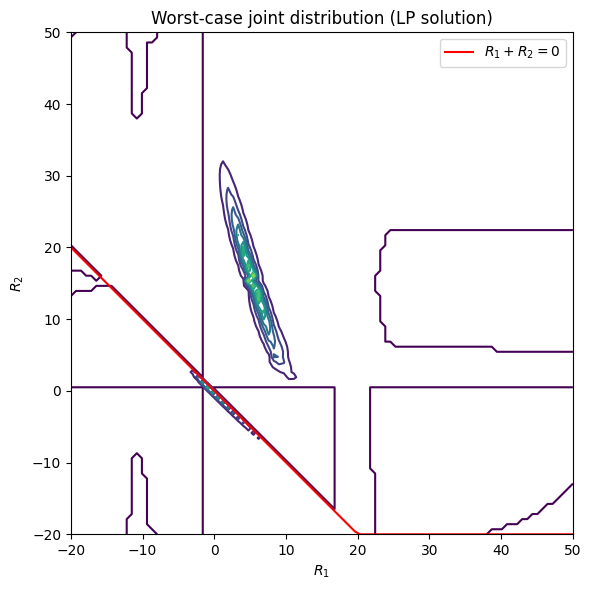

In [14]:
# Plot the worst-case joint distribution
P_opt = P.value  # optimal n x n joint distribution

plt.rcParams['figure.figsize'] = [6, 6]
fig, ax = plt.subplots()
ax.set_aspect('equal')

# Contour plot of optimal joint distribution
X, Y = np.meshgrid(r, r)
ax.contour(X, Y, P_opt.T, levels=10)

# Red line: R1 + R2 = 0  (boundary of the loss region)
ax.plot(r, np.clip(-r, -20, 50), color='r', label='$R_1+R_2=0$')

ax.set_xlabel('$R_1$')
ax.set_ylabel('$R_2$')
ax.set_title('Worst-case joint distribution (LP solution)')
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

The worst-case joint distribution found by the LP is **not smooth** — it concentrates all probability mass on a small number of $(R_1, R_2)$ pairs (an LP solution is always a vertex of the feasible polytope, which for this problem corresponds to a *sparse* distribution). 

Key observations:
- The worst-case $p^\text{loss}$ is **much larger** than ~0.018 (the jointly Gaussian value), showing that knowing only the marginals and correlation leaves a large degree of freedom for adversarial joint distributions.
- The LP pushes probability mass toward the region $r_i + r_j \leq 0$ (below the red line) as much as possible, subject to the marginal and correlation constraints.
- The sparse, line-like structure of the contours reflects the LP vertex nature: probability is concentrated on a few $(R_1, R_2)$ pairs, unlike the smooth Gaussian joint distribution.